# NaiveBayes & SVM using TF-IDF Benchmark - Symptoms Disease Classification

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from datasets import load_dataset, concatenate_datasets
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

os.makedirs("./results/naive_bayes", exist_ok=True)
os.makedirs("./results/svm", exist_ok=True)

## Load Dataset

In [8]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds   = ds["validation"].rename_column("text_cleaned", "text")
test_ds  = ds["test"].rename_column("text_cleaned", "text")

# Merge val + test
test_ds = concatenate_datasets([val_ds, test_ds])

print(f"Train : {len(train_ds)}")
print(f"Test  : {len(test_ds)}")

Train : 23541
Test  : 7848


In [5]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

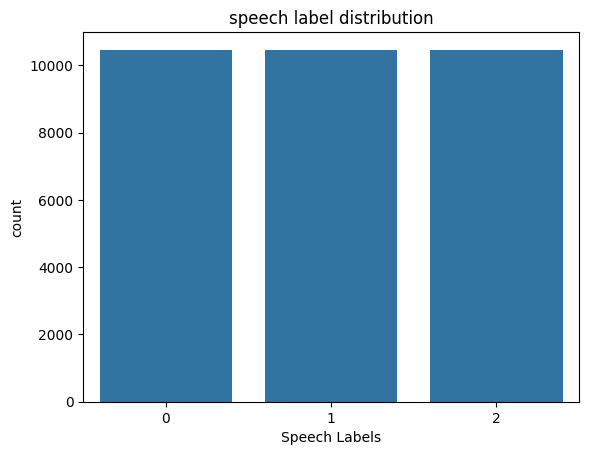

In [6]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [11]:
X_train = train_ds["text"]
y_train = train_ds["label"]
X_test  = test_ds["text"]
y_test  = test_ds["label"]

total_labels = len(set(train_ds["label"]))
id2label = {0: "hate", 1: "offensive", 2: "neither"}
label2id = {v: k for k, v in id2label.items()}

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Num classes: {total_labels}")

Train size : 23541
Test size  : 7848
Num classes: 3


## TF-IDF Vectorizer

In [12]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
)

# Fit on training data only — same principle as fitting tokenizer on train split
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (23541, 48716)
TF-IDF matrix shape (test) : (7848, 48716)


In [13]:
def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"[{model_name}]  accuracy: {acc:.4f} | f1 (weighted): {f1:.4f}")
    return acc, f1

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

def show_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    return df_report

## Naive Bayes Model

In [14]:
nb_model = ComplementNB(alpha=0.1)   # alpha: Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)
nb_acc, nb_f1 = evaluate("Naive Bayes", y_test, nb_preds)

[Naive Bayes]  accuracy: 0.7229 | f1 (weighted): 0.7153


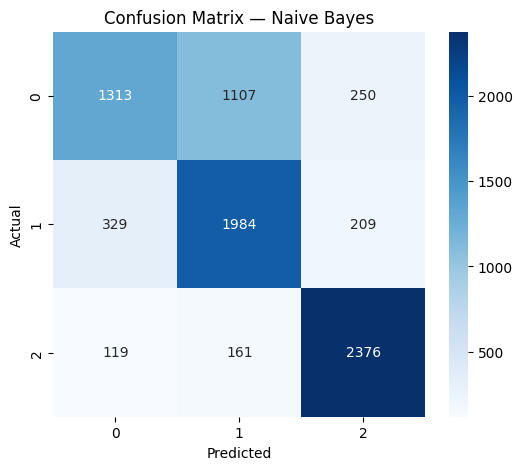

In [15]:
plot_confusion_matrix("Naive Bayes", y_test, nb_preds)

In [16]:
show_report(y_test, nb_preds)

,precision,recall,f1-score,support
0,0.745599,0.491760,0.592643,2670.000000
1,0.610086,0.786677,0.687219,2522.000000
2,0.838095,0.894578,0.865416,2656.000000
accuracy,0.722859,0.722859,0.722859,0.722859
macro avg,0.731260,0.724339,0.715092,7848.000000
weighted avg,0.733355,0.722859,0.715350,7848.000000


In [17]:
joblib.dump(nb_model, "./results/naive_bayes/model.pkl")
joblib.dump(tfidf,    "./results/naive_bayes/tfidf.pkl")

['./results/naive_bayes/tfidf.pkl']

## Support Vector Machine (SVM) Model

In [18]:
svm_base = LinearSVC(C=1.0, max_iter=2000)
svm_model = CalibratedClassifierCV(svm_base, cv=3)   # adds .predict_proba()
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_test_tfidf)
svm_acc, svm_f1 = evaluate("SVM", y_test, svm_preds)

[SVM]  accuracy: 0.7503 | f1 (weighted): 0.7457


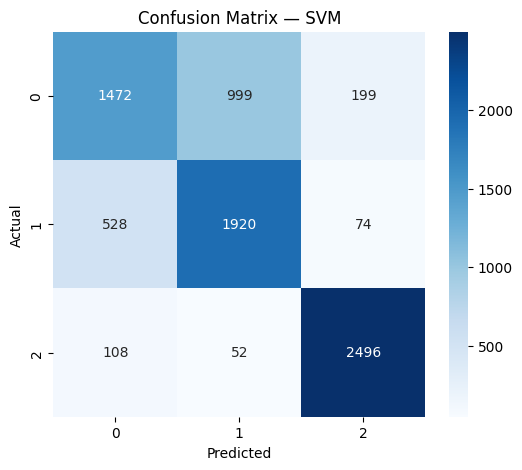

In [19]:
plot_confusion_matrix("SVM", y_test, svm_preds)

In [20]:
show_report(y_test, svm_preds)

,precision,recall,f1-score,support
0,0.698292,0.551311,0.616157,2670.000000
1,0.646247,0.761301,0.699072,2522.000000
2,0.901408,0.939759,0.920184,2656.000000
accuracy,0.750255,0.750255,0.750255,0.750255
macro avg,0.748649,0.750790,0.745138,7848.000000
weighted avg,0.750308,0.750255,0.745694,7848.000000


In [21]:
joblib.dump(svm_model, "./results/svm/model.pkl")
joblib.dump(tfidf,     "./results/svm/tfidf.pkl")

['./results/svm/tfidf.pkl']

## Inference Example

In [22]:
import joblib, json

nb_model  = joblib.load("./results/naive_bayes/model.pkl")
svm_model = joblib.load("./results/svm/model.pkl")
tfidf     = joblib.load("./results/naive_bayes/tfidf.pkl")  # same vectorizer for both

def predict(text, model, label_map):
    vec   = tfidf.transform([text])
    pred  = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    return [{"label": label_map[pred], "score": round(float(proba[pred]), 4)}]

test_text = "you are so stupid"

print("Naive Bayes:", predict(test_text, nb_model,  id2label))
print("SVM        :", predict(test_text, svm_model, id2label))

Naive Bayes: [{'label': 'hate', 'score': 0.4342}]
SVM        : [{'label': 'hate', 'score': 0.5057}]
